# Exploratory Data Analysis: Bank Transactions Dataset for Fraud Detection

---

## Business Context & Pain Points

ในอุตสาหกรรมธนาคาร **การตรวจจับธุรกรรมที่ผิดปกติ (Fraud Detection)** เป็นหนึ่งในปัญหาที่สำคัญที่สุด เนื่องจาก:

### Pain Points หลักของธุรกิจ

1. **ความเสียหายทางการเงิน** — ธุรกรรมฉ้อโกงที่ตรวจจับไม่ทันทำให้ธนาคารและลูกค้าสูญเสียเงิน
2. **ความล่าช้าในการตรวจจับ** — ระบบ Rule-based แบบเดิมอาจไม่สามารถจับรูปแบบ Fraud ที่ซับซ้อนได้
3. **False Positive สูง** — การแจ้งเตือนมากเกินไปทำให้ทีม Operation เสียเวลาตรวจสอบ และลูกค้าไม่พอใจ
4. **พฤติกรรมที่เปลี่ยนแปลง** — มิจฉาชีพปรับเปลี่ยนรูปแบบอยู่เสมอ ระบบต้องเรียนรู้ได้

### เป้าหมายของ Project นี้

- ทำความเข้าใจภาพรวมของข้อมูลธุรกรรม
- ค้นหา Pattern และ Anomaly ที่อาจบ่งชี้ถึงธุรกรรมที่ผิดปกติ
- เตรียมข้อมูลสำหรับการสร้างโมเดล ML/AI ในขั้นตอนถัดไป

---

## 1. Import Libraries & Load Data

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

# Load data
df = pd.read_csv('bank_transactions.csv')
print(f'Dataset shape: {df.shape[0]:,} rows x {df.shape[1]} columns')

Dataset shape: 50,000 rows x 15 columns


## 2. Data Overview — ภาพรวมข้อมูล

In [16]:
# ดูตัวอย่างข้อมูล 5 แถวแรก
df.head()

,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance
0,TX000001,AC00128,14.09,4/11/2023 16:29,Debit,San Diego,D000380,162.198.218.92,M015,ATM,70,Doctor,81,1,5112.21
1,TX000002,AC00455,376.24,6/27/2023 16:44,Debit,Houston,D000051,13.149.61.4,M052,ATM,68,Doctor,141,1,13758.91
2,TX000003,AC00019,126.29,7/10/2023 18:16,Debit,Mesa,D000235,215.97.143.157,M009,Online,19,Student,56,1,1122.35
3,TX000004,AC00070,184.50,5/5/2023 16:32,Debit,Raleigh,D000187,200.13.225.150,M002,Online,26,Student,25,1,8569.06
4,TX000005,AC00411,13.45,10/16/2023 17:51,Credit,Atlanta,D000308,65.164.3.100,M091,Online,26,Student,198,1,7429.40


In [17]:
# ดูโครงสร้างข้อมูล
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   TransactionID        50000 non-null  object 
 1   AccountID            50000 non-null  object 
 2   TransactionAmount    50000 non-null  float64
 3   TransactionDate      50000 non-null  object 
 4   TransactionType      50000 non-null  object 
 5   Location             50000 non-null  object 
 6   DeviceID             50000 non-null  object 
 7   IP Address           50000 non-null  object 
 8   MerchantID           50000 non-null  object 
 9   Channel              50000 non-null  object 
 10  CustomerAge          50000 non-null  int64  
 11  CustomerOccupation   50000 non-null  object 
 12  TransactionDuration  50000 non-null  int64  
 13  LoginAttempts        50000 non-null  int64  
 14  AccountBalance       50000 non-null  float64
dtypes: float64(2), int64(3), object(10)


In [18]:
# สถิติเชิงพรรณนาของตัวแปรเชิงตัวเลข
df.describe().round(2)

,TransactionAmount,CustomerAge,TransactionDuration,LoginAttempts,AccountBalance
count,50000.00,50000.00,50000.00,50000.00,50000.00
mean,297.87,44.65,118.97,1.13,5122.74
std,292.82,17.80,70.00,0.61,3904.27
min,0.24,18.00,10.00,1.00,101.25
25%,82.90,27.00,63.00,1.00,1508.72
50%,209.36,45.00,111.00,1.00,4735.41
75%,409.62,59.00,161.00,1.00,7713.67
max,2060.59,80.00,300.00,5.00,14977.99


In [19]:
# ตรวจสอบ Missing Values
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0]

if len(missing_df) > 0:
    print('Columns with Missing Values:')
    display(missing_df.sort_values('Missing %', ascending=False))
else:
    print('ไม่มี Missing Values ในชุดข้อมูลนี้')

ไม่มี Missing Values ในชุดข้อมูลนี้


In [20]:
# ตรวจสอบ Duplicate Transactions
dup_count = df.duplicated().sum()
dup_txn = df['TransactionID'].duplicated().sum()
print(f'Duplicate rows: {dup_count:,}')
print(f'Duplicate TransactionID: {dup_txn:,}')

Duplicate rows: 0
Duplicate TransactionID: 0


## 3. Categorical Variables — ตัวแปรเชิงกลุ่ม

In [21]:
# สรุปค่า Unique ของตัวแปร Categorical
cat_cols = ['TransactionType', 'Channel', 'Location', 'CustomerOccupation']
for col in cat_cols:
    print(f'\n--- {col} ({df[col].nunique()} unique values) ---')
    print(df[col].value_counts())


--- TransactionType (2 unique values) ---
TransactionType
Debit     38747
Credit    11253
Name: count, dtype: int64

--- Channel (3 unique values) ---
Channel
Branch    17278
ATM       16552
Online    16170
Name: count, dtype: int64

--- Location (43 unique values) ---
Location
Fort Worth          1396
Charlotte           1347
Oklahoma City       1345
Philadelphia        1343
Memphis             1330
Tucson              1322
Los Angeles         1318
Omaha               1298
Miami               1278
Denver              1267
Atlanta             1245
Detroit             1230
Mesa                1228
Houston             1217
Jacksonville        1216
Kansas City         1211
Seattle             1208
Boston              1203
Chicago             1195
San Antonio         1195
Raleigh             1187
Fresno              1177
San Jose            1159
Phoenix             1155
New York            1150
Austin              1146
Colorado Springs    1141
San Diego           1139
Las Vegas           

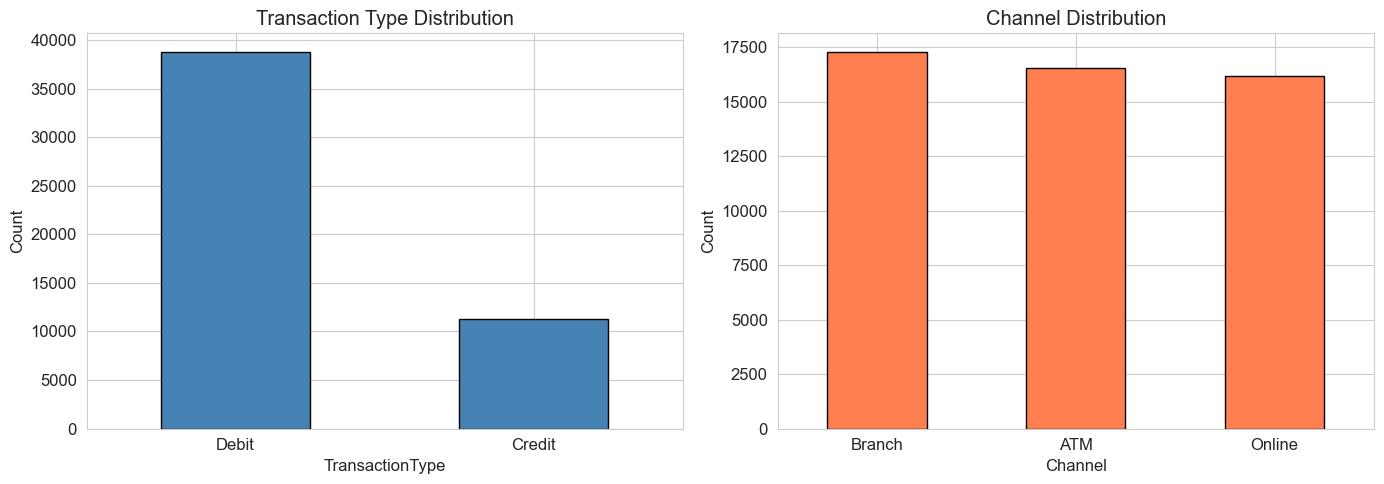

In [22]:
# Visualization: TransactionType & Channel
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df['TransactionType'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Transaction Type Distribution')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

df['Channel'].value_counts().plot(kind='bar', ax=axes[1], color='coral', edgecolor='black')
axes[1].set_title('Channel Distribution')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

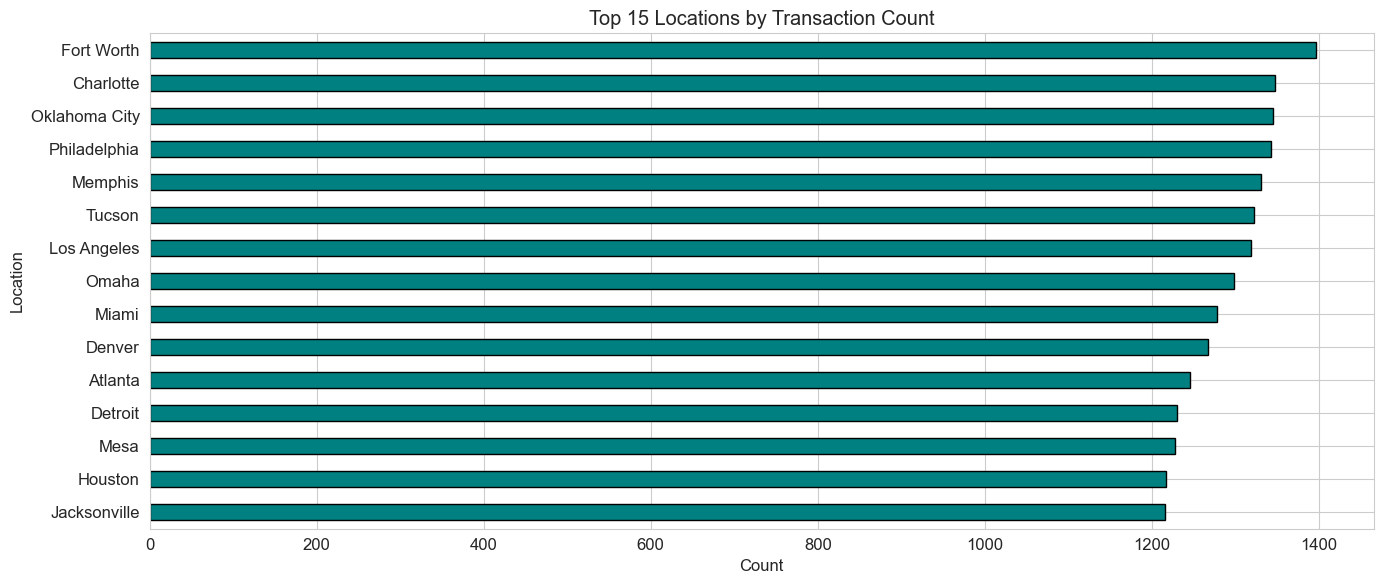

In [23]:
# Visualization: Top 15 Locations
fig, ax = plt.subplots(figsize=(14, 6))
df['Location'].value_counts().head(15).plot(kind='barh', ax=ax, color='teal', edgecolor='black')
ax.set_title('Top 15 Locations by Transaction Count')
ax.set_xlabel('Count')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

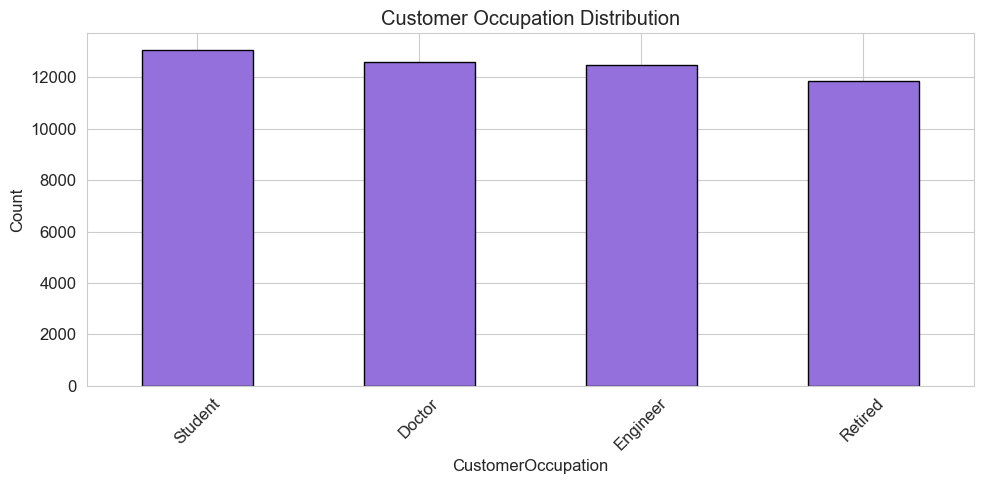

In [24]:
# Visualization: Customer Occupation
fig, ax = plt.subplots(figsize=(10, 5))
df['CustomerOccupation'].value_counts().plot(kind='bar', ax=ax, color='mediumpurple', edgecolor='black')
ax.set_title('Customer Occupation Distribution')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

## 4. Numerical Variables — ตัวแปรเชิงตัวเลข

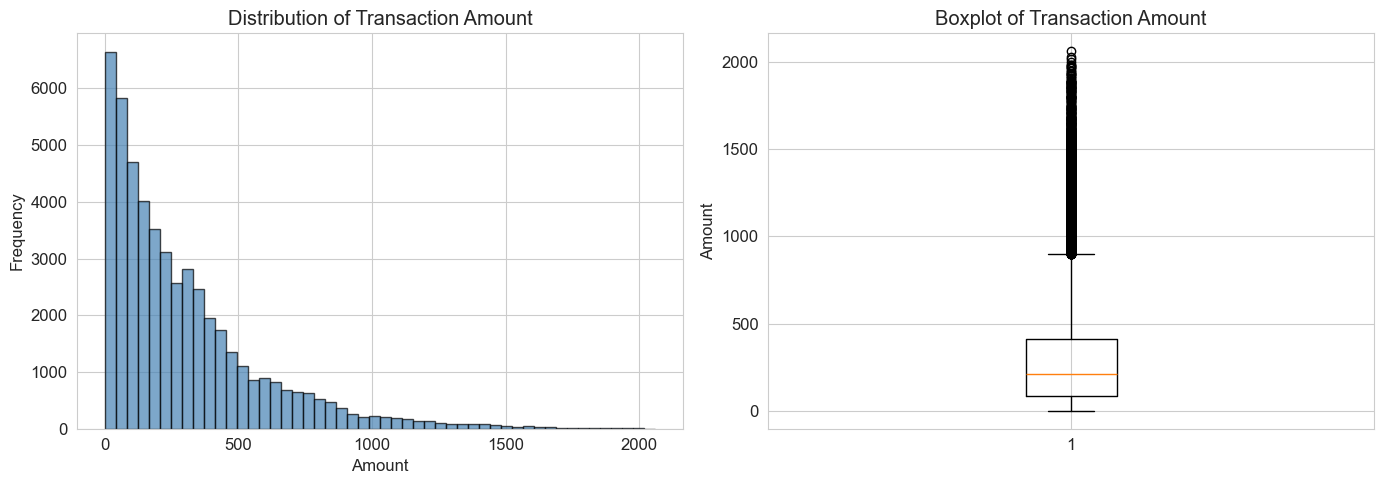

Mean: 297.87
Median: 209.36
Std: 292.82
Min: 0.24
Max: 2,060.59


In [25]:
# Distribution ของ TransactionAmount
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['TransactionAmount'], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_title('Distribution of Transaction Amount')
axes[0].set_xlabel('Amount')
axes[0].set_ylabel('Frequency')

axes[1].boxplot(df['TransactionAmount'], vert=True)
axes[1].set_title('Boxplot of Transaction Amount')
axes[1].set_ylabel('Amount')

plt.tight_layout()
plt.show()

print(f"Mean: {df['TransactionAmount'].mean():,.2f}")
print(f"Median: {df['TransactionAmount'].median():,.2f}")
print(f"Std: {df['TransactionAmount'].std():,.2f}")
print(f"Min: {df['TransactionAmount'].min():,.2f}")
print(f"Max: {df['TransactionAmount'].max():,.2f}")

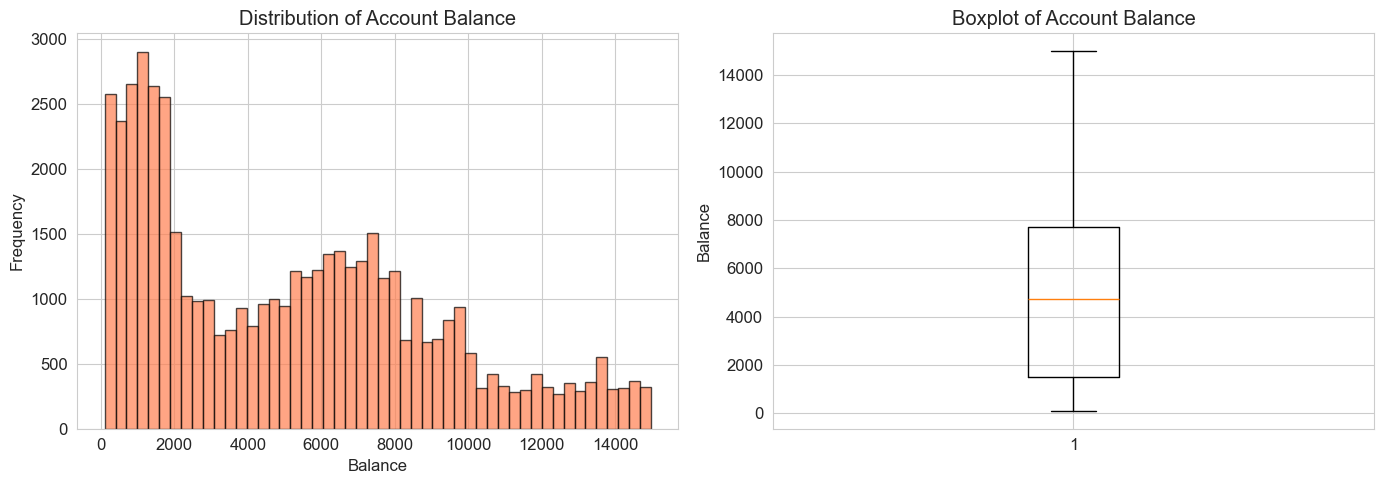

In [26]:
# Distribution ของ AccountBalance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['AccountBalance'], bins=50, color='coral', edgecolor='black', alpha=0.7)
axes[0].set_title('Distribution of Account Balance')
axes[0].set_xlabel('Balance')
axes[0].set_ylabel('Frequency')

axes[1].boxplot(df['AccountBalance'], vert=True)
axes[1].set_title('Boxplot of Account Balance')
axes[1].set_ylabel('Balance')

plt.tight_layout()
plt.show()

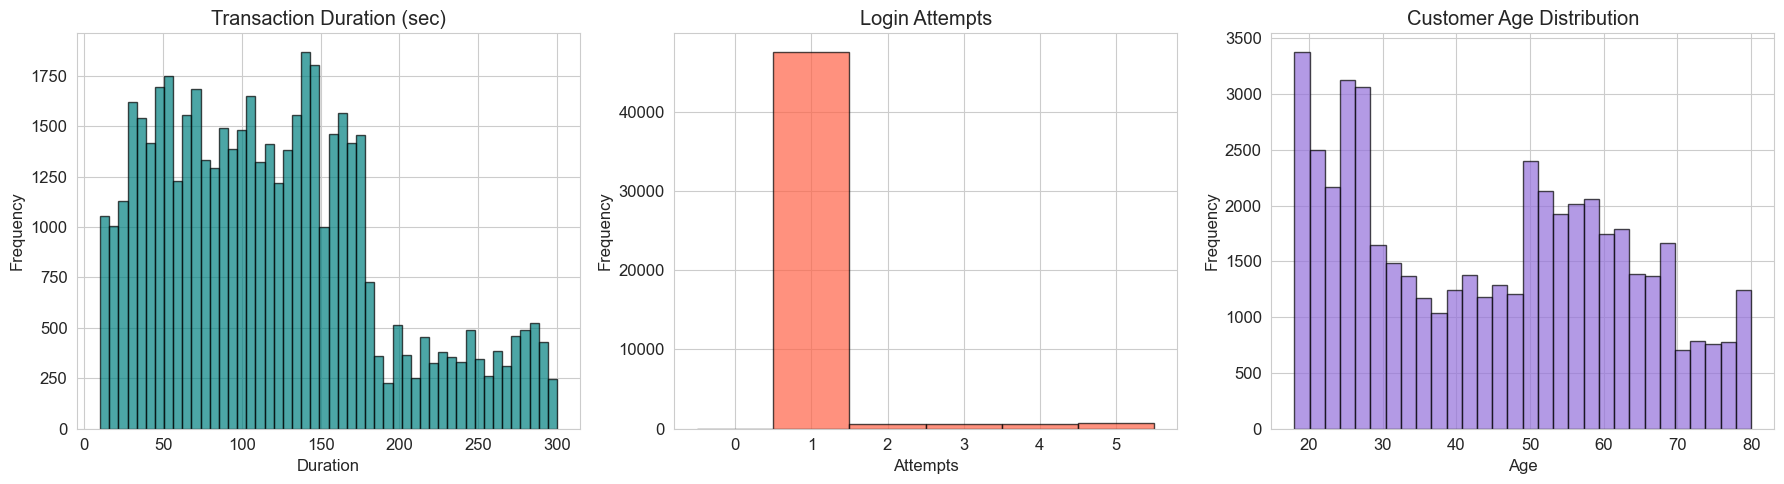

In [27]:
# Distribution ของ TransactionDuration, LoginAttempts, CustomerAge
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(df['TransactionDuration'], bins=50, color='teal', edgecolor='black', alpha=0.7)
axes[0].set_title('Transaction Duration (sec)')
axes[0].set_xlabel('Duration')

axes[1].hist(df['LoginAttempts'], bins=range(0, df['LoginAttempts'].max()+2), 
             color='tomato', edgecolor='black', alpha=0.7, align='left')
axes[1].set_title('Login Attempts')
axes[1].set_xlabel('Attempts')

axes[2].hist(df['CustomerAge'], bins=30, color='mediumpurple', edgecolor='black', alpha=0.7)
axes[2].set_title('Customer Age Distribution')
axes[2].set_xlabel('Age')

for ax in axes:
    ax.set_ylabel('Frequency')

plt.tight_layout()
plt.show()

## 5. Time-based Analysis — วิเคราะห์ตามเวลา

In [28]:
# แปลง TransactionDate เป็น datetime
df['TransactionDate'] = pd.to_datetime(df['TransactionDate'], format='mixed')
df['Hour'] = df['TransactionDate'].dt.hour
df['DayOfWeek'] = df['TransactionDate'].dt.day_name()
df['Month'] = df['TransactionDate'].dt.month
df['Date'] = df['TransactionDate'].dt.date

print(f"Date Range: {df['TransactionDate'].min()} to {df['TransactionDate'].max()}")

Date Range: 2020-01-01 00:00:00 to 2025-12-31 00:00:00


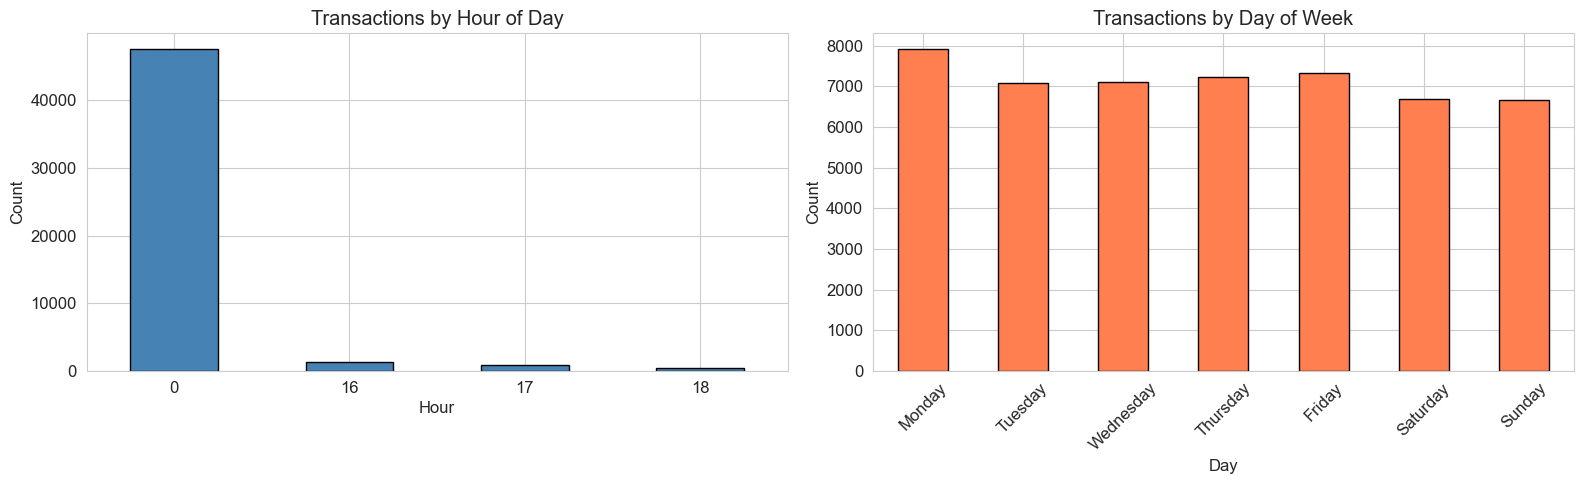

In [29]:
# ธุรกรรมตามชั่วโมงของวัน
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

df['Hour'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Transactions by Hour of Day')
axes[0].set_xlabel('Hour')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

# ธุรกรรมตามวันในสัปดาห์
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
df['DayOfWeek'].value_counts().reindex(day_order).plot(kind='bar', ax=axes[1], color='coral', edgecolor='black')
axes[1].set_title('Transactions by Day of Week')
axes[1].set_xlabel('Day')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

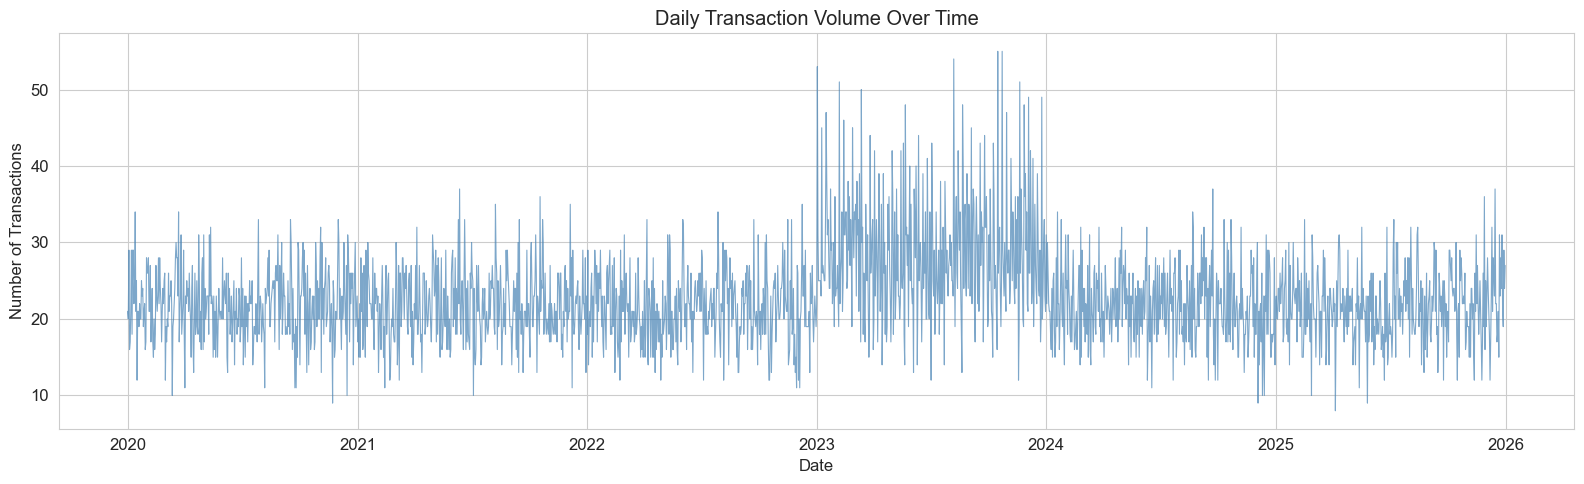

In [30]:
# Transaction Volume Over Time (Daily)
daily_txn = df.groupby('Date').size()

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(daily_txn.index, daily_txn.values, color='steelblue', alpha=0.7, linewidth=0.8)
ax.set_title('Daily Transaction Volume Over Time')
ax.set_xlabel('Date')
ax.set_ylabel('Number of Transactions')
plt.tight_layout()
plt.show()

## 6. Correlation Analysis — ความสัมพันธ์ระหว่างตัวแปร

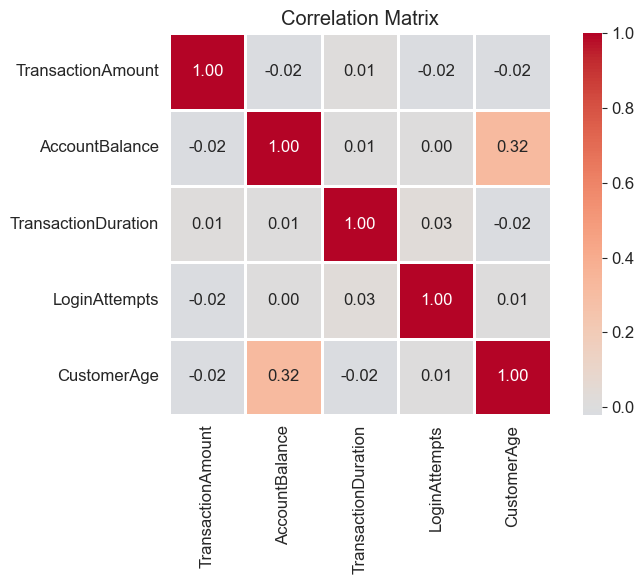

In [31]:
# Correlation Heatmap
num_cols = ['TransactionAmount', 'AccountBalance', 'TransactionDuration', 'LoginAttempts', 'CustomerAge']
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
            square=True, linewidths=1, ax=ax)
ax.set_title('Correlation Matrix')
plt.tight_layout()
plt.show()

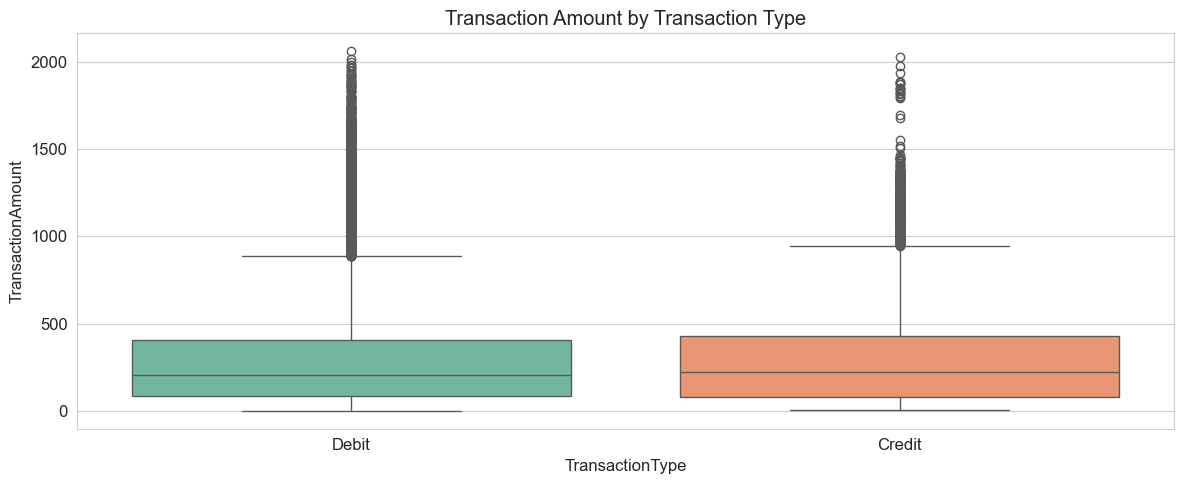

In [32]:
# TransactionAmount แยกตาม TransactionType
fig, ax = plt.subplots(figsize=(12, 5))
sns.boxplot(data=df, x='TransactionType', y='TransactionAmount', ax=ax, palette='Set2')
ax.set_title('Transaction Amount by Transaction Type')
plt.tight_layout()
plt.show()

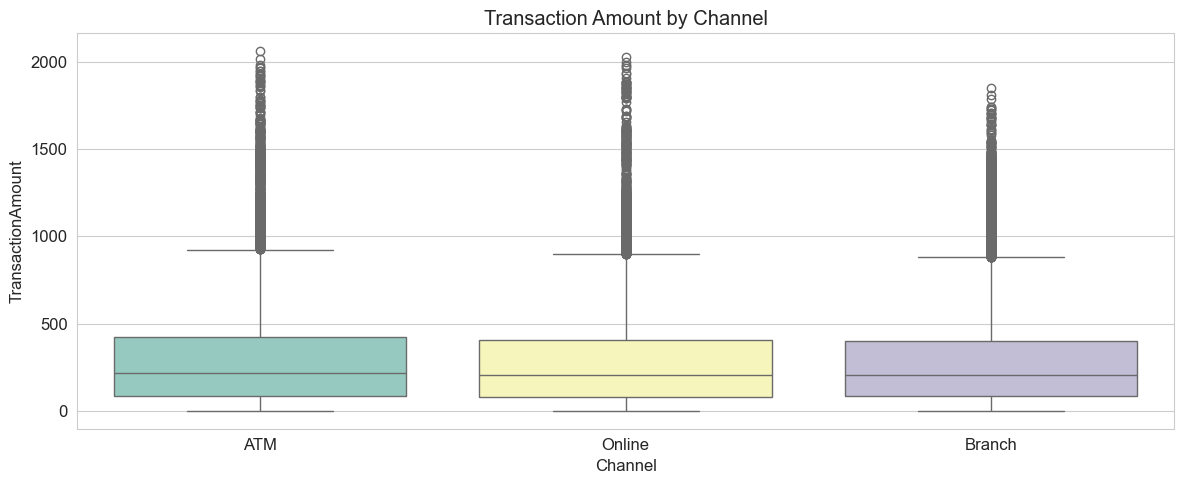

In [33]:
# TransactionAmount แยกตาม Channel
fig, ax = plt.subplots(figsize=(12, 5))
sns.boxplot(data=df, x='Channel', y='TransactionAmount', ax=ax, palette='Set3')
ax.set_title('Transaction Amount by Channel')
plt.tight_layout()
plt.show()

## 7. Anomaly Indicators — สัญญาณบ่งชี้ความผิดปกติ

ในส่วนนี้จะสำรวจตัวแปรที่อาจบ่งชี้ถึงธุรกรรมผิดปกติ เช่น
- ยอดเงินสูงผิดปกติ (Outliers)
- Login Attempts สูง (อาจเป็นการเดารหัสผ่าน)
- Device ที่ใช้งานหลายบัญชี
- บัญชีที่ทำรายการถี่ผิดปกติ

In [34]:
# 7.1 High Transaction Amount Outliers (IQR method)
Q1 = df['TransactionAmount'].quantile(0.25)
Q3 = df['TransactionAmount'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR

outliers = df[df['TransactionAmount'] > upper_bound]
print(f'IQR Upper Bound: {upper_bound:,.2f}')
print(f'Transactions above upper bound: {len(outliers):,} ({len(outliers)/len(df)*100:.2f}%)')
print(f'\nTop 10 highest transactions:')
outliers.nlargest(10, 'TransactionAmount')[['TransactionID', 'AccountID', 'TransactionAmount', 
                                             'TransactionType', 'Channel', 'LoginAttempts']]

IQR Upper Bound: 899.72
Transactions above upper bound: 2,375 (4.75%)

Top 10 highest transactions:


,TransactionID,AccountID,TransactionAmount,TransactionType,Channel,LoginAttempts
39962,TX039963,AC00423,2060.59,Debit,ATM,1
22802,TX022803,AC00179,2026.44,Credit,Online,1
16715,TX016716,AC00423,2014.32,Debit,ATM,1
46664,TX046665,AC00107,2001.83,Debit,Online,1
28432,TX028433,AC00423,1981.27,Debit,ATM,1
49522,TX049523,AC00107,1979.42,Debit,Online,1
10261,TX010262,AC00179,1974.46,Credit,Online,1
6708,TX006709,AC00423,1972.37,Debit,ATM,1
28802,TX028803,AC00107,1965.28,Debit,Online,1
46506,TX046507,AC00423,1962.35,Debit,ATM,1


Login Attempts Distribution:
LoginAttempts
1    47547
2      529
3      619
4      645
5      660
Name: count, dtype: int64

Transactions with 3+ login attempts: 1,924 (3.85%)


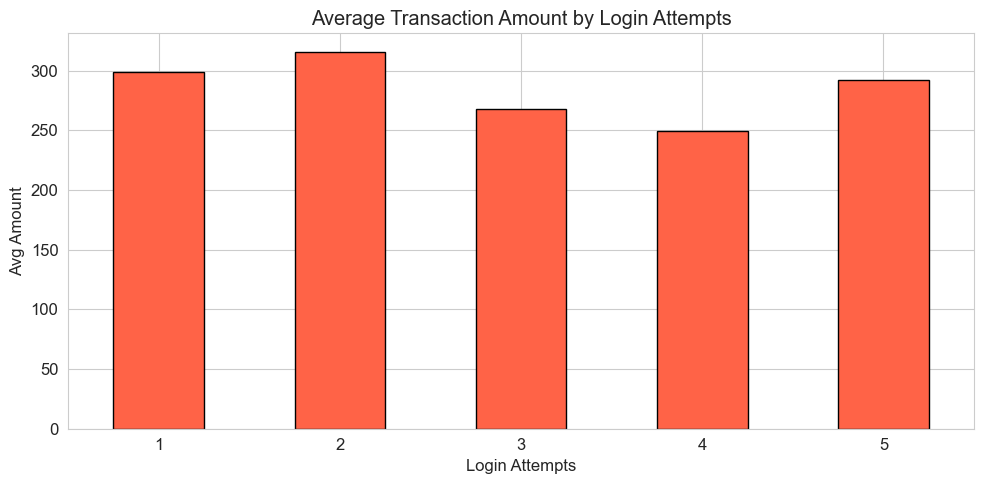

In [35]:
# 7.2 Login Attempts Analysis
print('Login Attempts Distribution:')
print(df['LoginAttempts'].value_counts().sort_index())

high_login = df[df['LoginAttempts'] >= 3]
print(f'\nTransactions with 3+ login attempts: {len(high_login):,} ({len(high_login)/len(df)*100:.2f}%)')

# เปรียบเทียบ LoginAttempts กับ TransactionAmount
fig, ax = plt.subplots(figsize=(10, 5))
df.groupby('LoginAttempts')['TransactionAmount'].mean().plot(kind='bar', ax=ax, 
                                                              color='tomato', edgecolor='black')
ax.set_title('Average Transaction Amount by Login Attempts')
ax.set_xlabel('Login Attempts')
ax.set_ylabel('Avg Amount')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

In [36]:
# 7.3 Device sharing — อุปกรณ์ที่ใช้กับหลายบัญชี
device_accounts = df.groupby('DeviceID')['AccountID'].nunique().reset_index()
device_accounts.columns = ['DeviceID', 'NumAccounts']
shared_devices = device_accounts[device_accounts['NumAccounts'] > 1]

print(f'Devices used by multiple accounts: {len(shared_devices):,}')
print(f'\nTop 10 most shared devices:')
shared_devices.nlargest(10, 'NumAccounts')

Devices used by multiple accounts: 609

Top 10 most shared devices:


,DeviceID,NumAccounts
140,D000142,9
198,D000203,9
304,D000315,9
436,D000451,9
531,D000548,9
643,D000663,9
677,D000697,9
36,D000037,8
45,D000046,8
127,D000129,8


In [37]:
# 7.4 Account Activity — บัญชีที่มีธุรกรรมมากผิดปกติ
account_activity = df.groupby('AccountID').agg(
    TxnCount=('TransactionID', 'count'),
    TotalAmount=('TransactionAmount', 'sum'),
    AvgAmount=('TransactionAmount', 'mean'),
    MaxAmount=('TransactionAmount', 'max'),
    UniqueDevices=('DeviceID', 'nunique'),
    UniqueLocations=('Location', 'nunique'),
    AvgLoginAttempts=('LoginAttempts', 'mean')
).round(2)

print('Top 10 accounts by transaction count:')
account_activity.nlargest(10, 'TxnCount')

Top 10 accounts by transaction count:


,TxnCount,TotalAmount,AvgAmount,MaxAmount,UniqueDevices,UniqueLocations,AvgLoginAttempts
AccountID,,,,,,,
AC00363,249,103323.12,414.95,1616.68,12,11,1.00
AC00202,241,75719.32,314.19,718.57,12,11,1.00
AC00460,238,111652.99,469.13,1888.52,12,9,1.18
AC00362,233,64739.42,277.85,789.90,12,10,1.00
AC00480,230,68732.92,298.84,1164.30,10,10,1.00
AC00304,225,70376.50,312.78,1239.86,11,9,1.09
AC00241,211,39474.05,187.08,493.47,8,8,1.24
AC00225,208,56635.92,272.29,688.28,11,10,1.25
AC00257,207,72612.25,350.78,1046.08,11,11,1.00


In [38]:
# 7.5 ยอดธุรกรรมตามช่วงเวลา — ธุรกรรมตอนดึก (00:00-05:00) อาจผิดปกติ
df['IsNightTime'] = df['Hour'].isin([0, 1, 2, 3, 4, 5])

night_txn = df[df['IsNightTime']]
day_txn = df[~df['IsNightTime']]

print(f'Night-time transactions (00:00-05:59): {len(night_txn):,} ({len(night_txn)/len(df)*100:.1f}%)')
print(f'Day-time transactions (06:00-23:59): {len(day_txn):,} ({len(day_txn)/len(df)*100:.1f}%)')
print(f'\nAvg Amount — Night: {night_txn["TransactionAmount"].mean():,.2f} vs Day: {day_txn["TransactionAmount"].mean():,.2f}')
print(f'Avg Login Attempts — Night: {night_txn["LoginAttempts"].mean():.2f} vs Day: {day_txn["LoginAttempts"].mean():.2f}')

Night-time transactions (00:00-05:59): 47,488 (95.0%)
Day-time transactions (06:00-23:59): 2,512 (5.0%)

Avg Amount — Night: 297.89 vs Day: 297.59
Avg Login Attempts — Night: 1.13 vs Day: 1.12


## 8. Summary & Key Findings

### สรุปภาพรวม
จากการวิเคราะห์ EDA เบื้องต้น เราได้ข้อมูลสำคัญเพื่อนำไปสร้างโมเดลต่อไป:

| หัวข้อ | สิ่งที่พบ |
|--------|----------|
| ขนาดข้อมูล | 50,000 ธุรกรรม |
| ช่วงเวลา | ดูจากผลลัพธ์ด้านบน |
| ตัวแปรสำคัญ | TransactionAmount, LoginAttempts, TransactionDuration, Channel |

### Next Steps
1. **Feature Engineering** — สร้างตัวแปรเพิ่มเติม เช่น ความถี่ธุรกรรมต่อบัญชี, ความเร็วในการใช้เงิน
2. **Anomaly Detection Models** — ใช้เทคนิค Unsupervised Learning เช่น Isolation Forest, DBSCAN
3. **Rule-based Flagging** — สร้างกฎเบื้องต้นจาก Pattern ที่พบ เช่น Login Attempts สูง + ยอดเงินสูง
4. **Dashboard** — สร้าง Dashboard เพื่อ Monitor ธุรกรรมแบบ Real-time

In [39]:
# สรุปข้อมูลสำคัญ
print('=' * 60)
print('DATASET SUMMARY')
print('=' * 60)
print(f'Total Transactions: {len(df):,}')
print(f'Unique Accounts: {df["AccountID"].nunique():,}')
print(f'Unique Devices: {df["DeviceID"].nunique():,}')
print(f'Unique Merchants: {df["MerchantID"].nunique():,}')
print(f'Unique Locations: {df["Location"].nunique():,}')
print(f'Transaction Types: {df["TransactionType"].unique().tolist()}')
print(f'Channels: {df["Channel"].unique().tolist()}')
print(f'Date Range: {df["TransactionDate"].min()} to {df["TransactionDate"].max()}')
print(f'Amount Range: {df["TransactionAmount"].min():,.2f} - {df["TransactionAmount"].max():,.2f}')
print('=' * 60)

DATASET SUMMARY
Total Transactions: 50,000
Unique Accounts: 495
Unique Devices: 681
Unique Merchants: 100
Unique Locations: 43
Transaction Types: ['Debit', 'Credit']
Channels: ['ATM', 'Online', 'Branch']
Date Range: 2020-01-01 00:00:00 to 2025-12-31 00:00:00
Amount Range: 0.24 - 2,060.59
